Download dei dati storici per AAPL in corso...


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532715,24.064278,23.346669,23.984543,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781898,24.839485,24.075362,24.192751,237458000


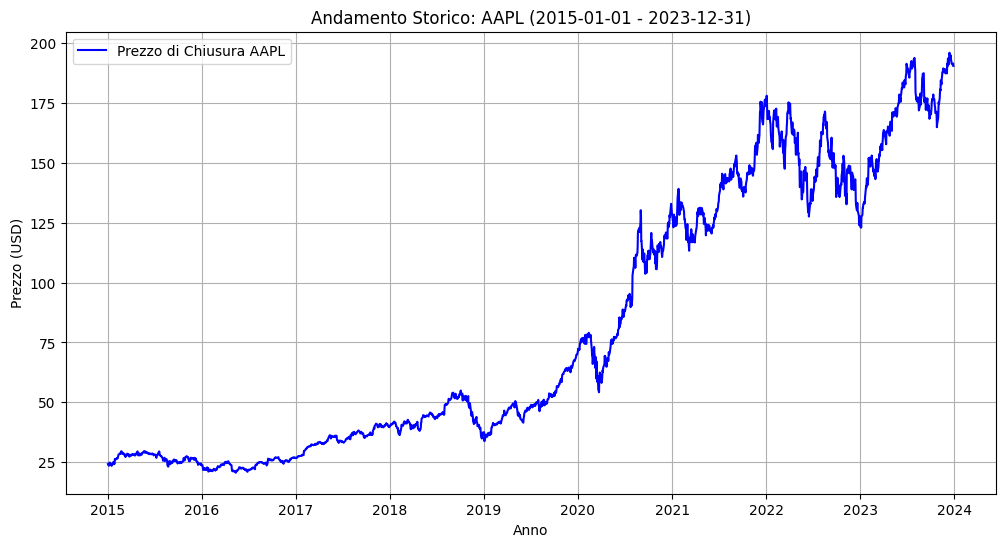


Totale giorni di borsa a disposizione: 2264


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


TICKER = 'AAPL' 
DATA_INIZIO = '2015-01-01'
DATA_FINE = '2023-12-31'
print(f"Download dei dati storici per {TICKER} in corso...")

df = yf.download(TICKER, start=DATA_INIZIO, end=DATA_FINE)
display(df.head())

#Il prezzo di chiusura
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(df.index, df['Close'], label=f'Prezzo di Chiusura {TICKER}', color='blue')
plt.title(f'Andamento Storico: {TICKER} ({DATA_INIZIO} - {DATA_FINE})')
plt.xlabel('Anno')
plt.ylabel('Prezzo (USD)')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nTotale giorni di borsa a disposizione: {len(df)}")

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

dataset = df['Close'].values
dataset = dataset.reshape(-1, 1)

# Normalizzazione 0-1
print("Normalizzazione dei dati in corso...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

print(f"Prezzo originale (es.): {dataset[0][0]:.2f}$ -> Prezzo scalato: {scaled_data[0][0]:.4f}")


# 80% iniziale per il train, 20% cronologico per il test.
training_data_len = int(np.ceil(len(dataset) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# Sliding Window (60 giorni)
window_size = 60

X_train = []
y_train = []

print(f"Creazione delle sequenze (finestra di {window_size} giorni)...")
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Le LSTM di Keras richiedono input tridimensionali: [Numero di campioni, Finestra temporale, Numero di Features]
# [X, 60 giorni, 1 feature (solo il prezzo Close)]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("\n--- RISULTATO DELLA PREPARAZIONE ---")
print(f"Forma di X_train (Input): {X_train.shape}")
print(f"Forma di y_train (Target): {y_train.shape}")

Normalizzazione dei dati in corso...
Prezzo originale (es.): 24.21$ -> Prezzo scalato: 0.0207
Creazione delle sequenze (finestra di 60 giorni)...

--- RISULTATO DELLA PREPARAZIONE ---
Forma di X_train (Input): (1752, 60, 1)
Forma di y_train (Target): (1752,)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

print("1. Assemblaggio dei moduli della Rete Neurale in corso...")

#inizializzazione "Rack"
model = Sequential()

#primo blocco LSTM
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))

#secondo blocco LSTM
model.add(LSTM(50, return_sequences=False))

#Intermedio
#raffinazione dei dati in uscita dalla LSTM
model.add(Dense(25))

#Output, prezzo previsto
model.add(Dense(1))

print("2. Configurazione del motore di apprendimento...")
model.compile(optimizer='adam', loss='mean_squared_error')

print("\n*** ARCHITETTURA COMPLETATA ***")
model.summary()

print("1. Avvio fase di Addestramento (Training)...")
print("Questa operazione richiederà un po' di tempo a seconda della CPU/GPU.")

#batch_size=32: Quanti "pacchetti" da 60 giorni analizza prima di aggiornare i pesi.
storia = model.fit(X_train, y_train, batch_size=32, epochs=10)

print("\n*** ADDESTRAMENTO COMPLETATO! ***")

1. Assemblaggio dei moduli della Rete Neurale in corso...
2. Configurazione del motore di apprendimento...

*** ARCHITETTURA COMPLETATA ***


c:\Users\Nicco\Desktop\Stuff\AI_Playground\RilevamentoFrodiDefalut\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

1. Avvio fase di Addestramento (Training)...
Questa operazione richiederà un po' di tempo a seconda della CPU/GPU.
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0146
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8926e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3700e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.2276e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.1717e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.1464e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.9059e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.9325e-04
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.7951e-04
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.8050e-04

*** ADDESTRAMENTO COMPLETATO! ***


Preparazione dei Dati di Test (con raccordo temporale)...
-> Dati di Test pronti! Finestre create: 452

Esecuzione delle Previsioni (Inference)...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Conversione dei numeri in dollari...

Generazione del Grafico Finale...


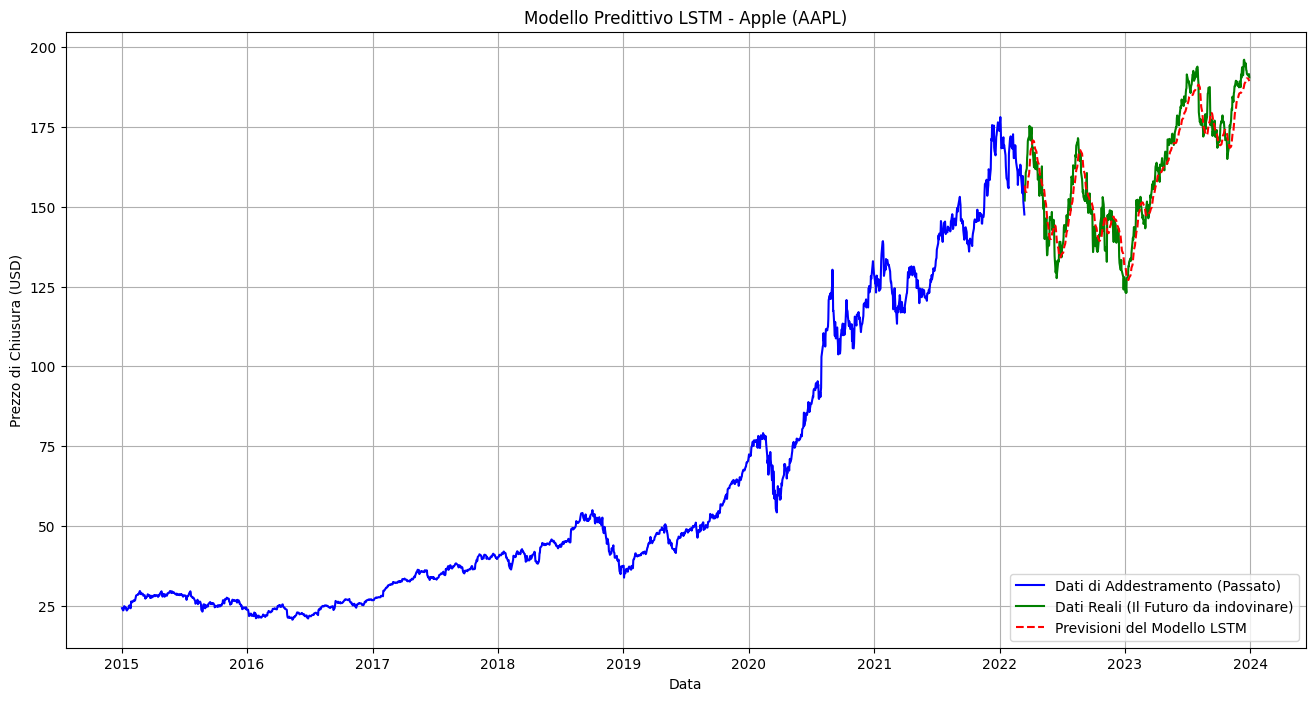

ERRORE MEDIO (RMSE): Il modello si sbaglia in media di 5.62 Dollari sul prezzo di chiusura.


In [4]:
print("Preparazione dei Dati di Test (con raccordo temporale)...")
test_data = scaled_data[training_data_len - 60: , :]

X_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"-> Dati di Test pronti! Finestre create: {X_test.shape[0]}")

print("\nEsecuzione delle Previsioni (Inference)...")
previsioni_scalate = model.predict(X_test)

print("Conversione dei numeri in dollari...")
previsioni_dollari = scaler.inverse_transform(previsioni_scalate)

print("\nGenerazione del Grafico Finale...")
train = df[:training_data_len].copy() #.copy() per evitare warning di Pandas
valid = df[training_data_len:].copy()

valid['Previsioni'] = previsioni_dollari

plt.figure(figsize=(16, 8), dpi=100)
plt.title('Modello Predittivo LSTM - Apple (AAPL)')
plt.xlabel('Data')
plt.ylabel('Prezzo di Chiusura (USD)')

plt.plot(train['Close'], color='blue', label='Dati di Addestramento (Passato)')
plt.plot(valid['Close'], color='green', label='Dati Reali (Il Futuro da indovinare)')
plt.plot(valid['Previsioni'], color='red', linestyle='dashed', label='Previsioni del Modello LSTM')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#errore medio in dollari
rmse = np.sqrt(np.mean(((previsioni_dollari - y_test) ** 2)))
print(f"ERRORE MEDIO (RMSE): Il modello si sbaglia in media di {rmse:.2f} Dollari sul prezzo di chiusura.")